In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'numpy'

In [ ]:
PARQUET_PATH   = "/home/anderson.clemente@orion.net/clnn_v2/outputs/eval/pred_gt_pairs_val.parquet"  # ajuste
OUTDIR         = "outputs/plots"
SPLIT          = "val"          # use None para não filtrar (ou "test")
USE_NORMALIZED = False          # False = usa x/y (0..199); True = usa *_norm (0..1)
GRIDSIZE       = 120            # resolução do hexbin
MAX_ROWS_TOTAL = 2_000_000      # amostra global (None para tudo)
MAX_ROWS_CITY  = 400_000        # amostra por cidade (None para tudo)
GRID_SIZE      = 200            # grade real (0..199)

# (opcional) rótulos humanos para o id de 'city'
CITY_LABELS = {0: "A", 1: "B", 2: "C", 3: "D"}

Path(OUTDIR).mkdir(parents=True, exist_ok=True)


In [18]:
def load_pred_gt(path, use_normalized: bool, split: str | None, max_rows_total: int | None):
    cols_real = ["city","x_pred","y_pred","x_gt","y_gt","split"]
    cols_norm = ["city","x_pred_norm","y_pred_norm","x_gt_norm","y_gt_norm","split"]
    cols = cols_norm if use_normalized else cols_real

    try:
        df = pd.read_parquet(path, columns=cols)
    except Exception:
        # se 'split' não existir, tenta sem ele
        cols = cols[:-1]
        df = pd.read_parquet(path, columns=cols)

    if split and "split" in df.columns:
        df = df[df["split"] == split]

    if max_rows_total and len(df) > max_rows_total:
        df = df.sample(n=max_rows_total, random_state=0)

    return df

df = load_pred_gt(PARQUET_PATH, USE_NORMALIZED, SPLIT, MAX_ROWS_TOTAL)
print(f"Linhas carregadas: {len(df):,} | cidades: {sorted(df['city'].unique().tolist())}")
df.head()


Linhas carregadas: 2,000,000 | cidades: [1, 2, 3]


,city,x_pred,y_pred,x_gt,y_gt,split
7887610,3,174.319199,54.436676,153.0,53.000004,val
6822425,2,48.133987,146.334290,27.0,151.000000,val
5479339,2,53.935108,168.694641,22.0,175.000000,val
8991239,3,26.032776,60.960255,12.0,62.000004,val
674627,1,54.687752,169.246017,45.0,175.000000,val


In [19]:
def hexbin_pred_vs_gt(x_gt, x_pred, title, lim=None, gridsize=100, save_path=None):
    plt.figure(figsize=(7, 6))
    hb = plt.hexbin(x_gt, x_pred, gridsize=gridsize, bins="log")  # densidade (log)
    cb = plt.colorbar(hb)
    cb.set_label("log10(contagem)")
    plt.title(title)
    plt.xlabel("Ground truth")
    plt.ylabel("Predição")

    # linha y = x
    if lim is None:
        lo = float(np.nanmin([x_gt.min(), x_pred.min()]))
        hi = float(np.nanmax([x_gt.max(), x_pred.max()]))
    else:
        lo, hi = lim
    plt.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

def plot_by_city(df, use_normalized, outdir, gridsize, max_rows_city, grid_size, city_labels=None):
    if use_normalized:
        xgt_col, xpd_col = "x_gt_norm", "x_pred_norm"
        ygt_col, ypd_col = "y_gt_norm", "y_pred_norm"
        lim = (0.0, 1.0)
        tag = "norm"
    else:
        xgt_col, xpd_col = "x_gt", "x_pred"
        ygt_col, ypd_col = "y_gt", "y_pred"
        lim = (0.0, float(grid_size - 1))
        tag = "real"

    for city_id in sorted(df["city"].unique()):
        sub = df[df["city"] == city_id]
        if max_rows_city and len(sub) > max_rows_city:
            sub = sub.sample(n=max_rows_city, random_state=0)

        label = city_labels.get(city_id, str(city_id)) if city_labels else str(city_id)
        split_tag = SPLIT or "all"

        # X
        hexbin_pred_vs_gt(
            x_gt=sub[xgt_col].to_numpy(),
            x_pred=sub[xpd_col].to_numpy(),
            title=f"Hexbin X — Cidade {label} ({tag}, split={split_tag})",
            lim=lim, gridsize=gridsize,
            save_path=Path(outdir) / f"hexbin_X_city-{label}_{tag}_split-{split_tag}.png"
        )
        # Y
        hexbin_pred_vs_gt(
            x_gt=sub[ygt_col].to_numpy(),
            x_pred=sub[ypd_col].to_numpy(),
            title=f"Hexbin Y — Cidade {label} ({tag}, split={split_tag})",
            lim=lim, gridsize=gridsize,
            save_path=Path(outdir) / f"hexbin_Y_city-{label}_{tag}_split-{split_tag}.png"
        )


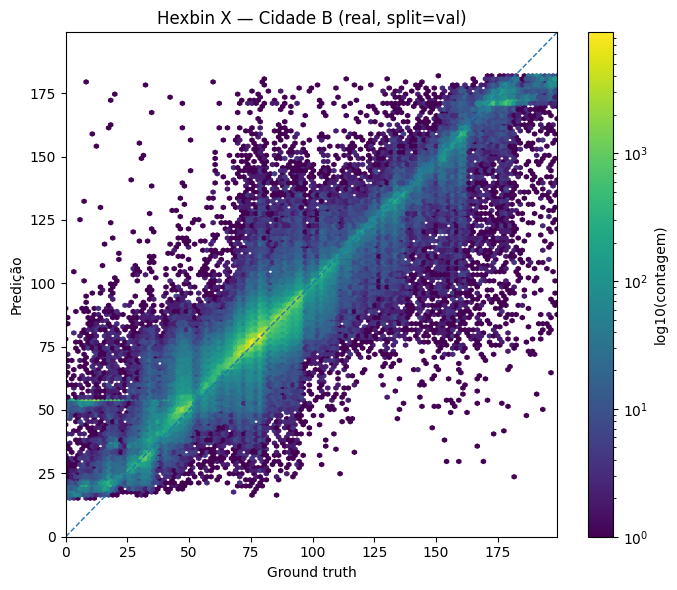

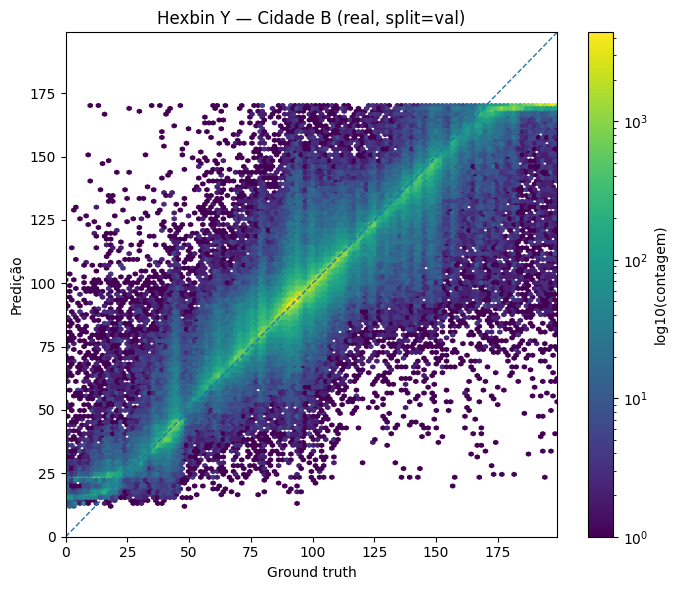

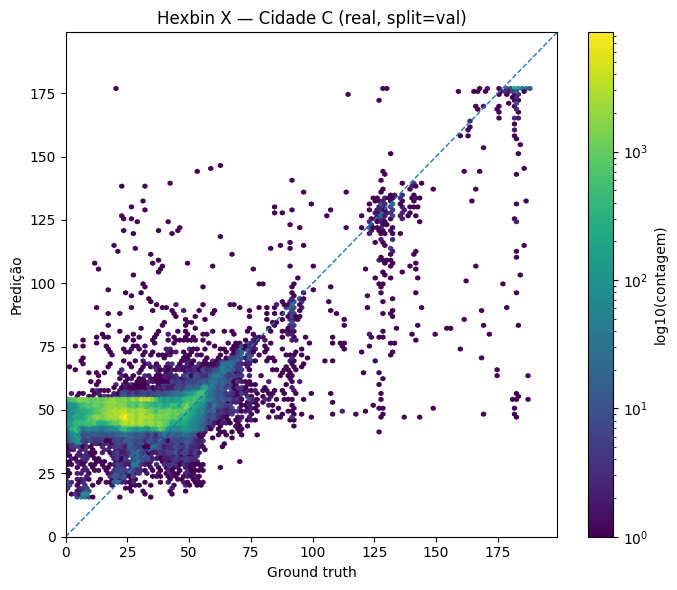

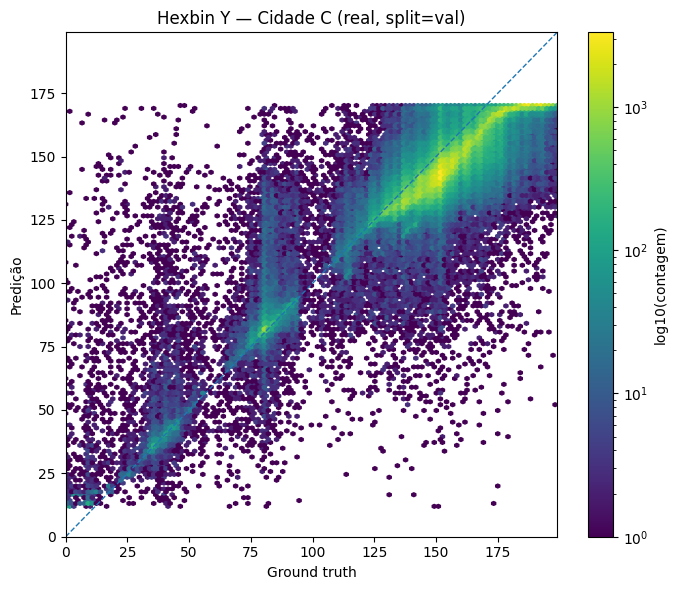

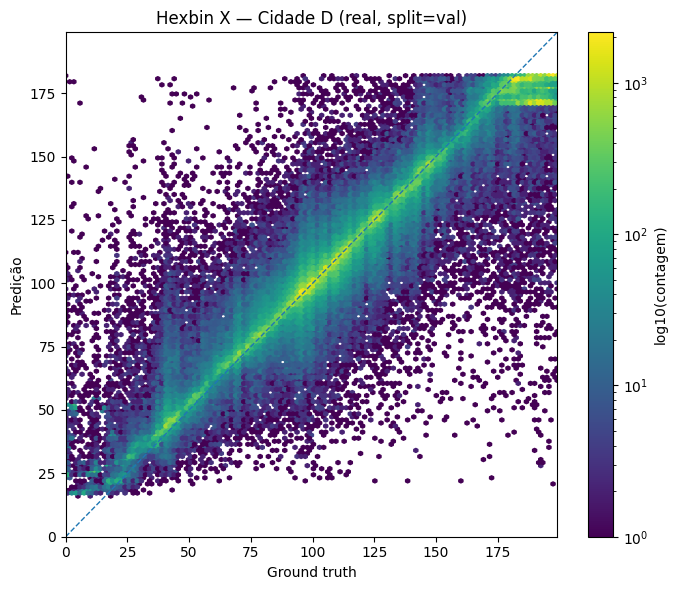

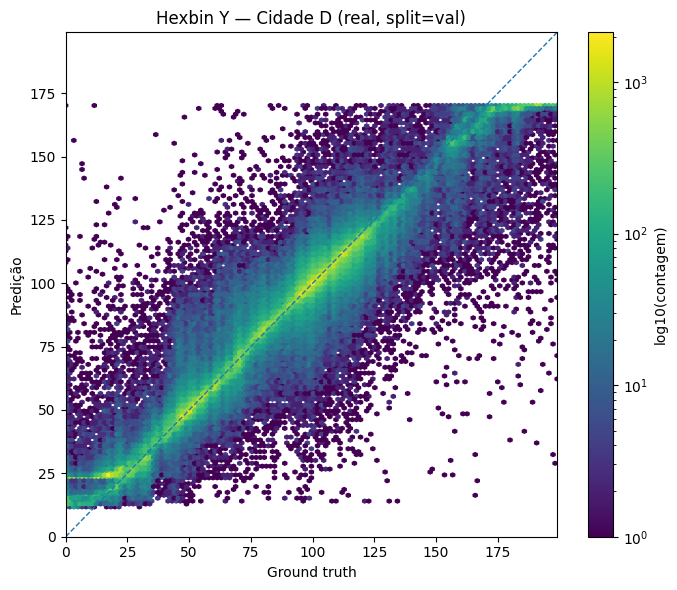

✔️ hexbins gerados por cidade em: outputs/plots


In [20]:
plot_by_city(
    df=df,
    use_normalized=USE_NORMALIZED,
    outdir=OUTDIR,
    gridsize=GRIDSIZE,
    max_rows_city=MAX_ROWS_CITY,
    grid_size=GRID_SIZE,
    city_labels=CITY_LABELS
)
print("✔️ hexbins gerados por cidade em:", OUTDIR)


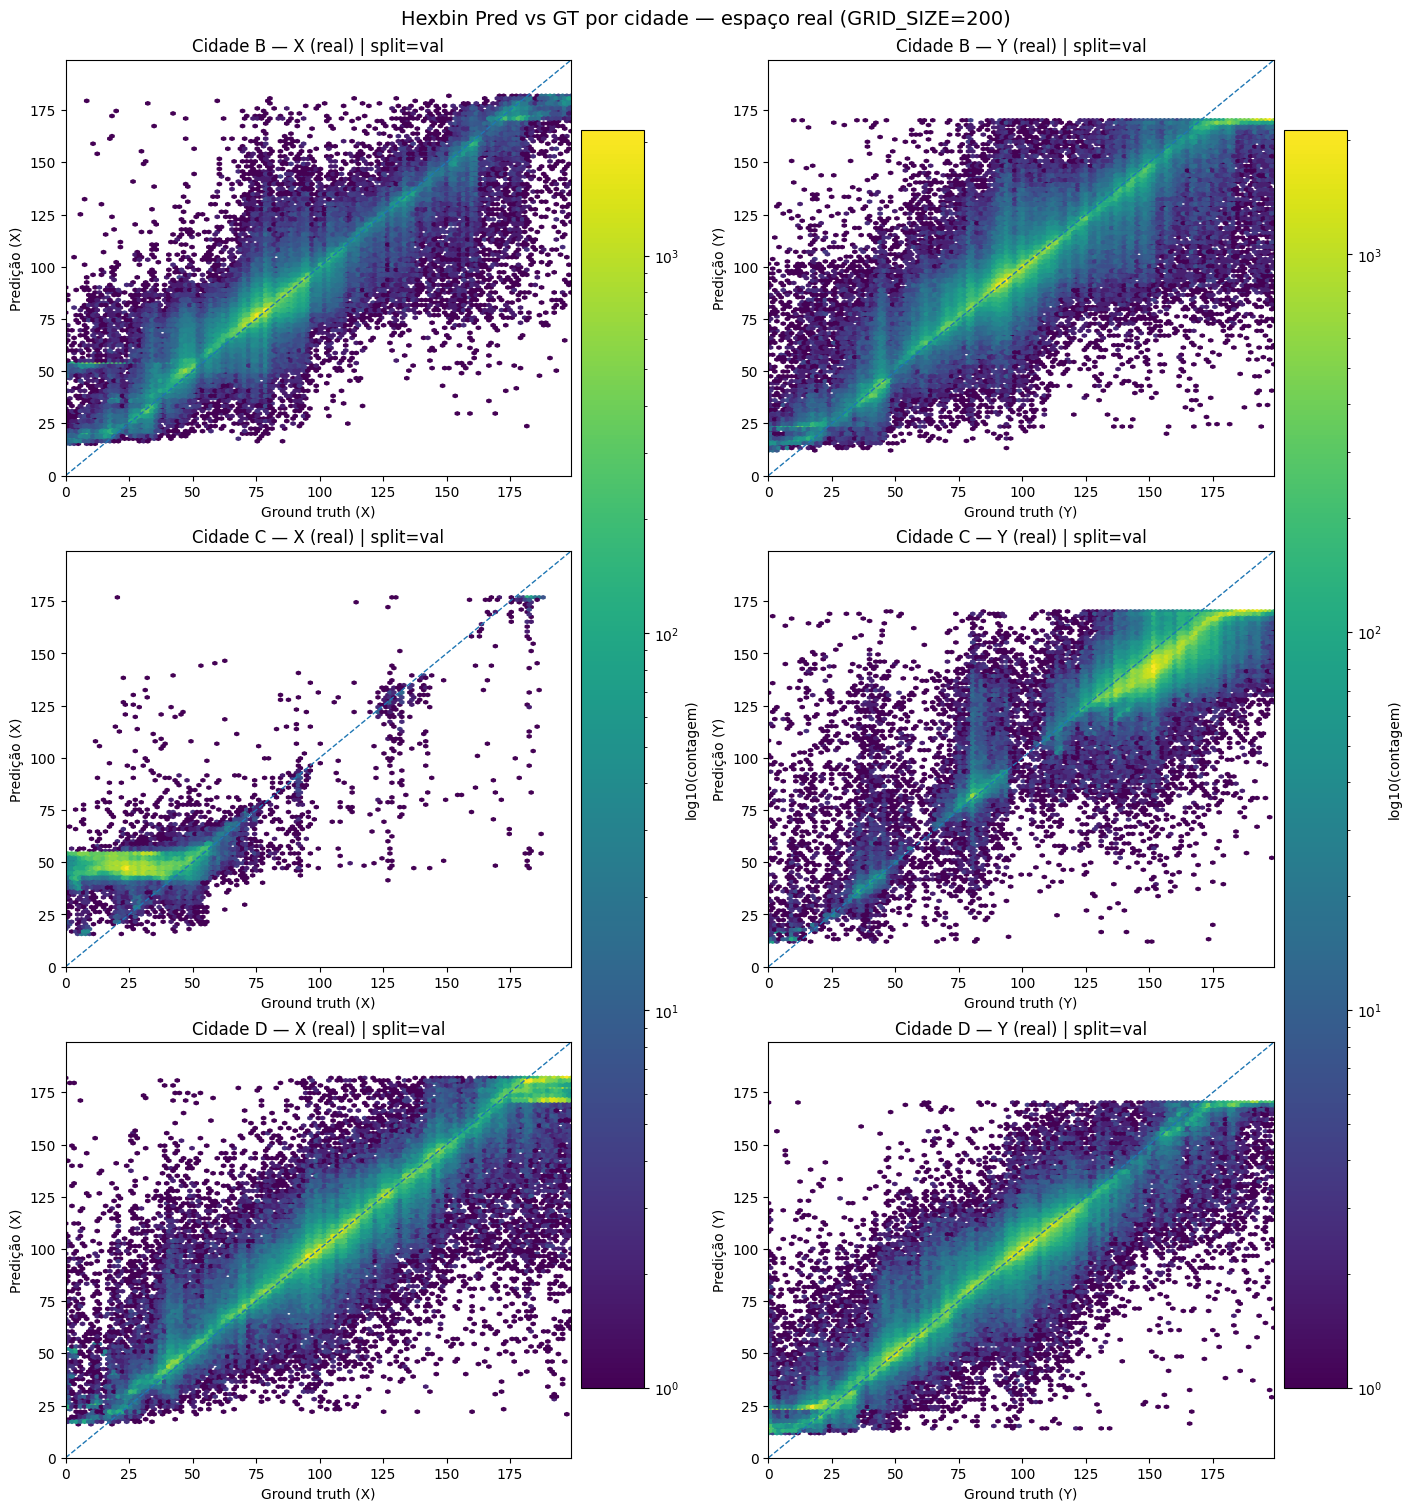

In [26]:
# 2 colunas (X e Y), 1 linha por cidade — coordenadas REAIS (0..GRID_SIZE-1)
cities = sorted(df["city"].unique())
n = len(cities)

fig, axes = plt.subplots(
    nrows=n, ncols=2,
    figsize=(14, 5*n),
    constrained_layout=True,              # ✅ em vez de tight_layout
)

# garante shape 2D mesmo se n==1
import numpy as np
axes = np.atleast_2d(axes)

lo, hi = 0.0, float(GRID_SIZE - 1)
split_tag = SPLIT or "all"

hb_x_last = None
hb_y_last = None

for i, city_id in enumerate(cities):
    sub = df[df["city"] == city_id]
    if MAX_ROWS_CITY and len(sub) > MAX_ROWS_CITY:
        sub = sub.sample(n=MAX_ROWS_CITY, random_state=0)

    label = CITY_LABELS.get(city_id, str(city_id)) if "CITY_LABELS" in globals() else str(city_id)

    # Coluna 0: X (GT vs Pred)
    axx = axes[i, 0]
    hb_x_last = axx.hexbin(
        sub["x_gt"].to_numpy(), sub["x_pred"].to_numpy(),
        gridsize=GRIDSIZE, bins="log"
    )
    axx.plot([lo, hi], [lo, hi], "--", lw=1)
    axx.set_title(f"Cidade {label} — X (real) | split={split_tag}")
    axx.set_xlabel("Ground truth (X)")
    axx.set_ylabel("Predição (X)")
    axx.set_xlim(lo, hi); axx.set_ylim(lo, hi)

    # Coluna 1: Y (GT vs Pred)
    axy = axes[i, 1]
    hb_y_last = axy.hexbin(
        sub["y_gt"].to_numpy(), sub["y_pred"].to_numpy(),
        gridsize=GRIDSIZE, bins="log"
    )
    axy.plot([lo, hi], [lo, hi], "--", lw=1)
    axy.set_title(f"Cidade {label} — Y (real) | split={split_tag}")
    axy.set_xlabel("Ground truth (Y)")
    axy.set_ylabel("Predição (Y)")
    axy.set_xlim(lo, hi); axy.set_ylim(lo, hi)

# ✅ barras de cor compartilhadas por coluna (não ficam por cima e não colidem)
cbar_x = fig.colorbar(hb_x_last, ax=axes[:, 0], orientation="vertical", shrink=0.9, pad=0.02)
cbar_x.set_label("log10(contagem)")
cbar_y = fig.colorbar(hb_y_last, ax=axes[:, 1], orientation="vertical", shrink=0.9, pad=0.02)
cbar_y.set_label("log10(contagem)")

fig.suptitle(f"Hexbin Pred vs GT por cidade — espaço real (GRID_SIZE={GRID_SIZE})", fontsize=14)
plt.savefig(Path(OUTDIR) / f"hexbin_pred_vs_gt_by_city_real_split-{split_tag}.png", dpi=150)
plt.show()


In [22]:
# Jupyter cell (opcional)
mae_x = np.mean(np.abs(x_pd - x_gt))
mae_y = np.mean(np.abs(y_pd - y_gt))
rmse_x = np.sqrt(np.mean((x_pd - x_gt)**2))
rmse_y = np.sqrt(np.mean((y_pd - y_gt)**2))
print(f"MAE X={mae_x:.4f} | Y={mae_y:.4f} | RMSE X={rmse_x:.4f} | Y={rmse_y:.4f}")


MAE X=12.3177 | Y=8.8413 | RMSE X=17.8829 | Y=13.7088
